{'topic': '猫咪', 'poem': '## 《猫》\n\n它的瞳孔是子夜，它的绒毛\n被整个冬天藏起。\n它踱步，延续优雅的形体，\n在月光铺就的瓦片上，径自离去。\n它从未留意我的注视，\n我也不曾将某片暗影认出。\n\n它的脊背，是流动的沙丘，\n它跃下，将某段曲线\n遗落在静止的虚空。\n它拨弄线团，也拨弄时间，\n在窗帘的波纹里，把玩自身。\n它厌倦了，便走开，\n留下半局残棋，和毛线球。\n\n它有九条命，却只用一种姿态，\n卧成瓷器的冷。\n它敛起利爪，也敛起红尘，\n在某个午后，突然老去。', 'joke': '一只猫走进酒吧。  \n酒保说：“我们这儿不招待猫。”  \n猫说：“我就用一下猫砂盆。”  \n酒保：“那也得消费。”  \n猫点了一杯牛奶，喝了一口，然后把杯子推到地上。  \n酒保：“你干什么？”  \n猫淡定地说：“小费。我们猫给的小费，讲究一个落地有声。”'}


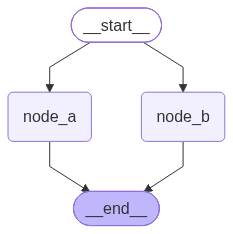

In [1]:
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_edge(START,"node_a")
builder.add_edge(START,"node_b")

builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪"})
print(res)

from IPython.display import display
display(graph)
